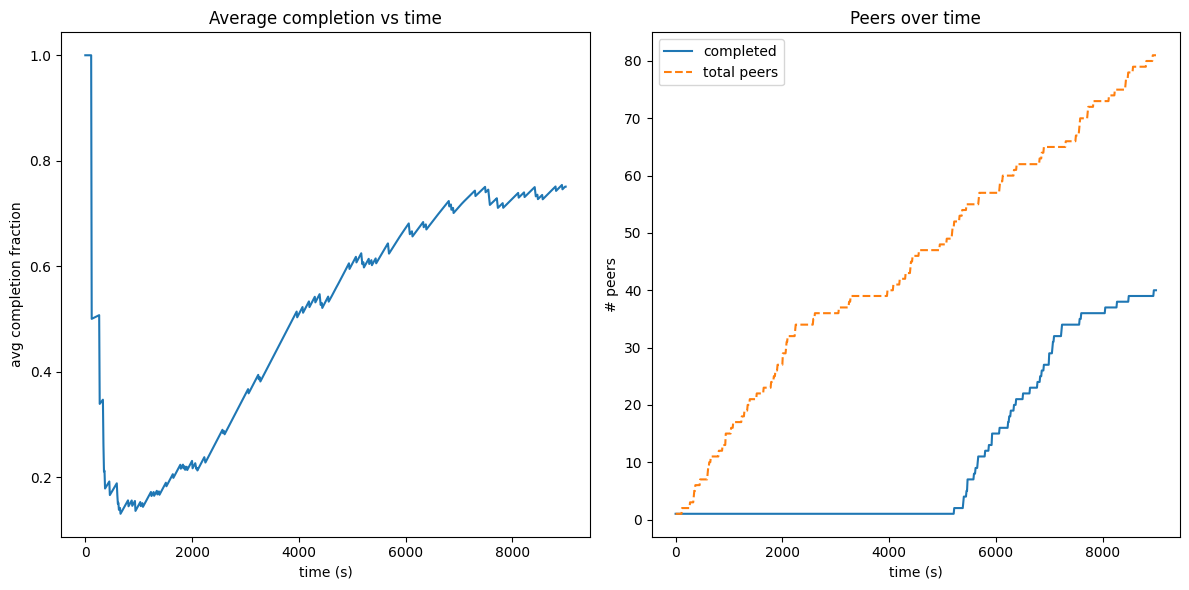

In [ ]:
#auto reload
%load_ext autoreload
%autoreload 2

from torrent_sim.config import default_config
from torrent_sim.core.engine import run_timestep_sim
import matplotlib.pyplot as plt


cfg = default_config()
cfg.time.max_time = 9000.0
cfg.time.dt = 10
cfg.arrival.max_peers = 2000
cfg.arrival.arrival_rate = 1/(2*60)  # 1 peer every 10 minutes

result = run_timestep_sim(cfg)
m = result.metrics

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].plot(m.times, m.avg_completion_fraction)
axes[0].set_xlabel("time (s)")
axes[0].set_ylabel("avg completion fraction")
axes[0].set_title("Average completion vs time")

axes[1].plot(m.times, m.num_completed_peers, label="completed")
axes[1].plot(m.times, m.num_peers, label="total peers", linestyle="--")
axes[1].set_xlabel("time (s)")
axes[1].set_ylabel("# peers")
axes[1].set_title("Peers over time")
axes[1].legend()

plt.tight_layout()
plt.show()

# # plot on a single figure/axis, using a secondary y-axis for peer counts (no subplots)
# fig = plt.figure(figsize=(10, 6))
# ax = plt.gca()

# # primary axis: completion fraction
# l1, = ax.plot(m.times, m.avg_completion_fraction, color='C0', label='avg completion fraction')
# ax.set_xlabel("time (s)")
# ax.set_ylabel("avg completion fraction", color='C0')
# ax.tick_params(axis='y', labelcolor='C0')

# # secondary axis: peer counts
# ax2 = ax.twinx()
# l2, = ax2.plot(m.times, m.num_completed_peers, color='C1', label='completed')
# l3, = ax2.plot(m.times, m.num_peers, color='C2', linestyle="--", label='total peers')
# ax2.set_ylabel("# peers", color='C1')
# ax2.tick_params(axis='y', labelcolor='C1')

# # combined legend
# lines = [l1, l2, l3]
# labels = [ln.get_label() for ln in lines]
# ax.legend(lines, labels, loc="best")

# ax.set_title("Completion and peers over time")
# plt.tight_layout()
# plt.show()

printing a few peer states at the end:

In [ ]:
result

In [ ]:
from collections import Counter
Counter([p.bandwidth.kind for p in result.swarm.peers.values()])

In [ ]:
peers = sorted(
    result.swarm.peers.values(),
    key=lambda p: (p.completed_time is None, p.completed_time if p.completed_time is not None else float('inf'))
)

for p in peers:
    print(p.peer_id, p.num_pieces_owned, p.completed_time, p.bandwidth.kind)
